# Testing Bayes Opt with multipeaked gaussians

In [21]:
import sys
import os
from tqdm.notebook import tqdm # Import tqdm for notebook progress bars
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import re # For sanitizing filenames
from bayes_opt import BayesianOptimization
from bayes_opt.acquisition import ExpectedImprovement, UpperConfidenceBound # Import specific acquisitions
from tqdm.notebook import tqdm # Import tqdm for notebook progress bars
import copy # To deep copy acquisition function if needed
sys.path.append(os.path.abspath('..'))
from venus_ml import generate_shifted_noisy_gaussian, generate_styblinski_tang, BayesOptimizer, generate_multi_peak_gaussian

## Function Examples

Generated 1D function: multiPeakGauss_d1_p3_ag1p5_al0p6_alphag3p0_alphal1p0_n0.01
1D Peak Locations (Global First):
[[-0.63158276]
 [ 2.62769065]
 [-1.68683153]]

Plotting 1D Function...


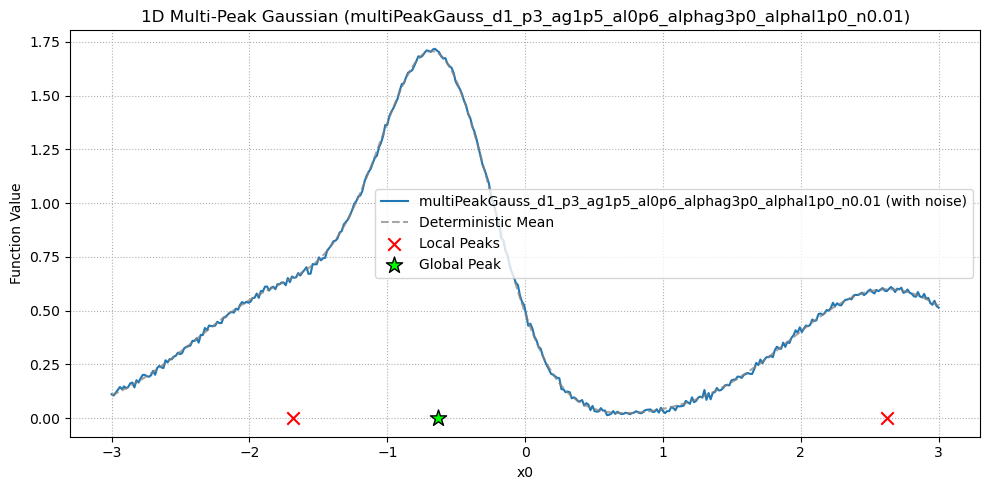

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
# Assuming generate_multi_peak_gaussian is defined/imported from previous context

# --- Generate and Plot 1D Multi-Peak Gaussian ---

# 1. Define Parameters for 1D function
dim_1d = 1
n_peaks_1d = 3
amp_global_1d = 1.5
amp_local_1d = 0.6
alpha_global_1d = 3.0 # Relatively sharp peaks
alpha_local_1d = 1.0
lower_1d = -3.0
upper_1d = 3.0
noise_1d = 0.01
seed_1d = 667

# 2. Generate the 1D function
func_1d, pbounds_1d, peaks_1d = generate_multi_peak_gaussian(
    dim=dim_1d,
    n_peaks=n_peaks_1d,
    amplitude_global=amp_global_1d,
    amplitude_local=amp_local_1d,
    alpha_global=alpha_global_1d,
    alpha_local=alpha_local_1d,
    lower=lower_1d,
    upper=upper_1d,
    noise=noise_1d,
)
print(f"Generated 1D function: {func_1d.__name__}")
print("1D Peak Locations (Global First):")
print(peaks_1d['shifts'])

# 3. Plot the 1D function
print("\nPlotting 1D Function...")
fig_1d, ax_1d = plt.subplots(figsize=(10, 5))

# Create x values for plotting
x_plot = np.linspace(lower_1d, upper_1d, 400)
y_plot = np.array([func_1d(x0=val) for val in x_plot]) # Evaluate func_1d

# Plot the function line
ax_1d.plot(x_plot, y_plot, label=f'{func_1d.__name__} (with noise)')

# Optionally plot the deterministic part (without noise)
if noise_1d > 0:
     # Need to temporarily create a noise-free version or recalculate
     y_deterministic = np.zeros_like(x_plot)
     shifts_arr = peaks_1d['shifts']
     amplitudes_arr = peaks_1d['amplitudes']
     alphas_arr = peaks_1d['alphas']
     for i in range(len(x_plot)):
         x_val = np.array([x_plot[i]]) # Make it 1D array for distance calc
         total_val = 0.0
         for p_idx in range(n_peaks_1d):
             distance_sq = np.sum((x_val - shifts_arr[p_idx])**2)
             peak_val = amplitudes_arr[p_idx] * np.exp(-alphas_arr[p_idx] * distance_sq)
             total_val += peak_val
         y_deterministic[i] = total_val
     ax_1d.plot(x_plot, y_deterministic, '--', color='gray', alpha=0.7, label='Deterministic Mean')


# Plot peak locations
shifts = peaks_1d['shifts']
global_idx = peaks_1d.get('global_peak_index', 0)
# Plot local peaks
local_indices = [i for i in range(len(shifts)) if i != global_idx]
if local_indices:
     ax_1d.scatter(shifts[local_indices, 0], np.zeros_like(shifts[local_indices, 0]),
                   c='red', marker='x', s=80, label='Local Peaks', zorder=5) # zorder to bring markers on top
# Plot global peak
ax_1d.scatter(shifts[global_idx, 0], 0,
              c='lime', marker='*', s=150, label='Global Peak', edgecolors='black', zorder=5)

ax_1d.set_xlabel('x0')
ax_1d.set_ylabel('Function Value')
ax_1d.set_title(f"1D Multi-Peak Gaussian ({func_1d.__name__})")
ax_1d.legend()
ax_1d.grid(True, linestyle=':')
plt.tight_layout()
plt.show()



Generated 2D function: multiPeakGauss_d2_p5_ag1p5_al0p6_alphag5p0_alphal1p0_n0.00
2D Peak Locations (Global First):
[[ 1.88738099  2.30187488]
 [-1.07965263  2.09938286]
 [ 0.20018385  1.52987603]
 [ 2.42426058  2.02589544]
 [-0.30251969  0.23333882]]

Plotting 2D Heatmap...


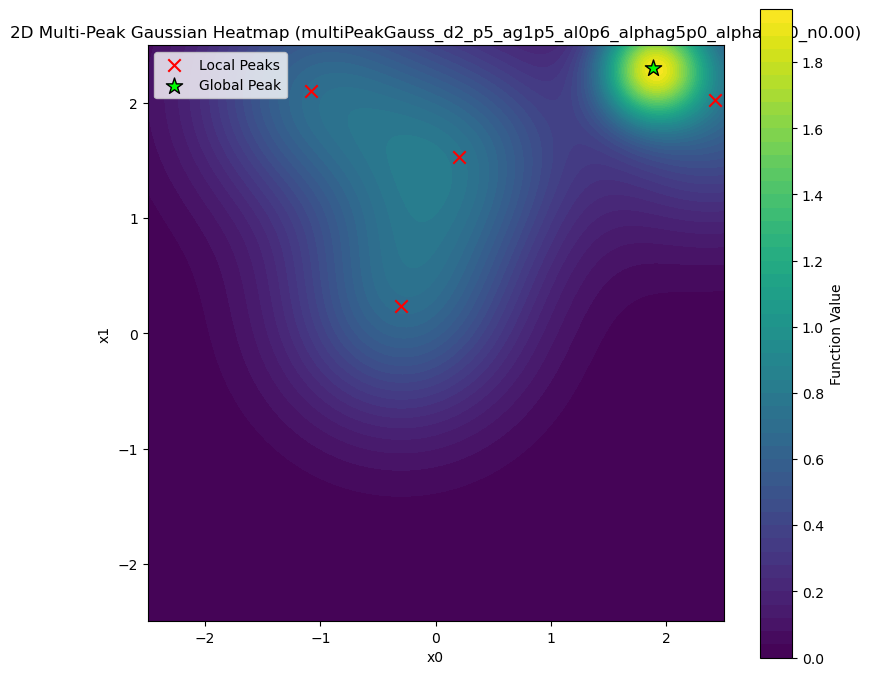


Plotting 3D Surface...


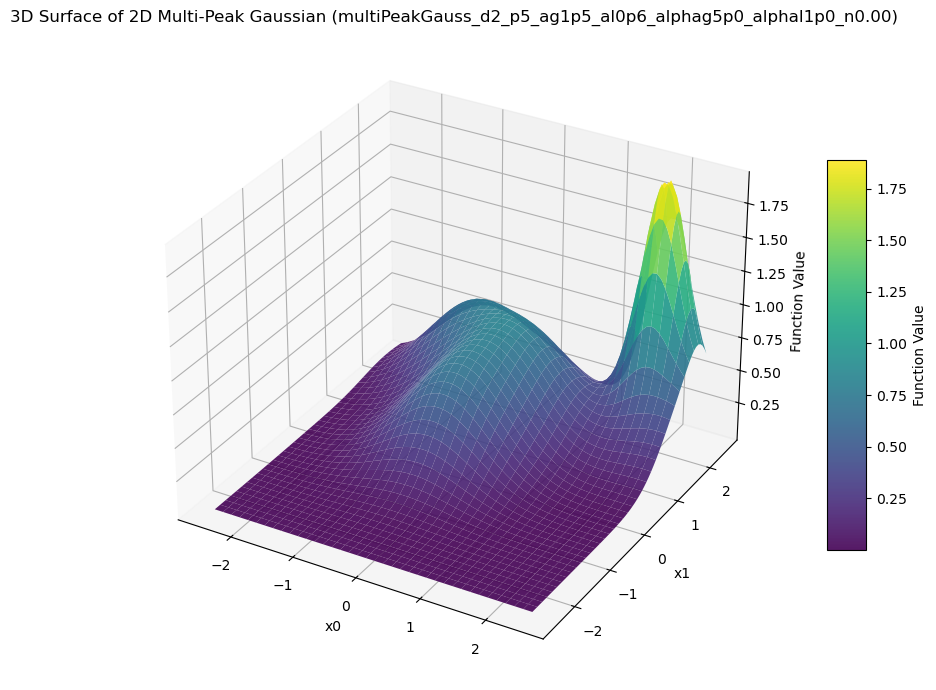

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from mpl_toolkits.mplot3d import Axes3D # For 3D plotting
# Assuming generate_multi_peak_gaussian is defined/imported from previous context

# --- Generate and Plot 2D Multi-Peak Gaussian ---

# 1. Define Parameters for 2D function
dim_2d = 2
n_peaks_2d = 5
amp_global_2d = 1.5
amp_local_2d = 0.6
alpha_global_2d = 5.0 # Sharper global peak
alpha_local_2d = 1.0
lower_2d = -2.5
upper_2d = 2.5
noise_2d = 0.0
seed_2d = 888

# 2. Generate the 2D function
func_2d, pbounds_2d, peaks_2d = generate_multi_peak_gaussian(
    dim=dim_2d,
    n_peaks=n_peaks_2d,
    amplitude_global=amp_global_2d,
    amplitude_local=amp_local_2d,
    alpha_global=alpha_global_2d,
    alpha_local=alpha_local_2d,
    lower=lower_2d,
    upper=upper_2d,
    noise=noise_2d,
)
print(f"Generated 2D function: {func_2d.__name__}")
print("2D Peak Locations (Global First):")
print(peaks_2d['shifts'])

# 3. Plot the 2D function Heatmap
print("\nPlotting 2D Heatmap...")
fig_hm, ax_hm = plt.subplots(figsize=(8, 7))
resolution_2d = 150 # Higher resolution for smoother plot

x0_bounds = pbounds_2d['x0']
x1_bounds = pbounds_2d['x1']
x0_lin = np.linspace(x0_bounds[0], x0_bounds[1], resolution_2d)
x1_lin = np.linspace(x1_bounds[0], x1_bounds[1], resolution_2d)
xx0, xx1 = np.meshgrid(x0_lin, x1_lin)

# Evaluate function on the grid
Z_hm = np.zeros_like(xx0)
for i in range(resolution_2d):
    for j in range(resolution_2d):
        kwargs = {'x0': xx0[i, j], 'x1': xx1[i, j]}
        Z_hm[i, j] = func_2d(**kwargs)

cont = ax_hm.contourf(xx0, xx1, Z_hm, levels=50, cmap='viridis')
fig_hm.colorbar(cont, ax=ax_hm, label='Function Value')

# Plot peak locations
shifts = peaks_2d['shifts']
global_idx = peaks_2d.get('global_peak_index', 0)
# Plot local peaks
local_indices = [i for i in range(len(shifts)) if i != global_idx]
if local_indices:
     ax_hm.scatter(shifts[local_indices, 0], shifts[local_indices, 1],
                   c='red', marker='x', s=80, label='Local Peaks', zorder=5)
# Plot global peak
ax_hm.scatter(shifts[global_idx, 0], shifts[global_idx, 1],
              c='lime', marker='*', s=150, label='Global Peak', edgecolors='black', zorder=5)
ax_hm.legend()

ax_hm.set_xlabel('x0')
ax_hm.set_ylabel('x1')
ax_hm.set_title(f"2D Multi-Peak Gaussian Heatmap ({func_2d.__name__})")
ax_hm.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()


# 4. Plot the 2D function as a 3D Surface
print("\nPlotting 3D Surface...")
fig_3d = plt.figure(figsize=(10, 7))
ax_3d = fig_3d.add_subplot(111, projection='3d')
resolution_3d = 75 # Medium resolution for surface

# Reuse grid if resolution is the same, otherwise recalculate if needed
# (Using separate resolution here for demonstration)
x0_lin_3d = np.linspace(x0_bounds[0], x0_bounds[1], resolution_3d)
x1_lin_3d = np.linspace(x1_bounds[0], x1_bounds[1], resolution_3d)
xx0_3d, xx1_3d = np.meshgrid(x0_lin_3d, x1_lin_3d)

# Evaluate function on the grid
Z_3d = np.zeros_like(xx0_3d)
for i in range(resolution_3d):
    for j in range(resolution_3d):
        kwargs = {'x0': xx0_3d[i, j], 'x1': xx1_3d[i, j]}
        Z_3d[i, j] = func_2d(**kwargs)

surf = ax_3d.plot_surface(xx0_3d, xx1_3d, Z_3d, cmap='viridis', edgecolor='none', alpha=0.9)

# Optionally add contour lines at the bottom
# cset = ax_3d.contourf(xx0_3d, xx1_3d, Z_3d, zdir='z', offset=np.min(Z_3d)*1.1, cmap='viridis', alpha=0.5)

ax_3d.set_xlabel('x0')
ax_3d.set_ylabel('x1')
ax_3d.set_zlabel('Function Value')
ax_3d.set_title(f"3D Surface of 2D Multi-Peak Gaussian ({func_2d.__name__})")
fig_3d.colorbar(surf, shrink=0.6, aspect=10, label='Function Value') # Add color bar to 3D plot
plt.tight_layout()
plt.show()


## Experiments

### Alpha Ratio 2:1

Generated 5D function: multiPeakGauss_d9_p6_ag1p9_al0p6_alphag2p0_alphal1p0_n0.00
Calculated Deterministic Max Value: 1.900000

--- Running Single 9D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---
Using known true maximum for comparison: 1.900000

Starting single optimization run: 50 random, max 950 acquisition steps.
Using Acquisition Function: UpperConfidenceBound (kappa10p00)


Random Exploration:   0%|          | 0/50 [00:00<?, ?it/s]

Acquisition Phase :   0%|          | 0/950 [00:00<?, ?it/s]


--- Single Run Finished ---
Optimization finished after 1000 iterations.
Best value found (Observed): 0.422649
Best value found (GP Max):   0.422649
Best parameters found: {'x0': -0.8802177505214359, 'x1': 1.5822375993723496, 'x2': 0.06924379460216956, 'x3': -1.6237420154190079, 'x4': -0.3140761289017513, 'x5': -0.3073866649667234, 'x6': -0.11570503531246557, 'x7': 0.7552162834428366, 'x8': -0.7797237701676957}
Difference from Known True Max (1.900000): 1.477351 (77.7553%)
---------------------------
Summary plot saved to toy_bayes/bayesopt_summary_multiPeakGauss_d9_p6_ag1p9_al0p6_alphag2p0_alphal1p0_n0.00_d9_UpperConfidenceBound_kappa10p00_r50_a950_i1000_noseed.png


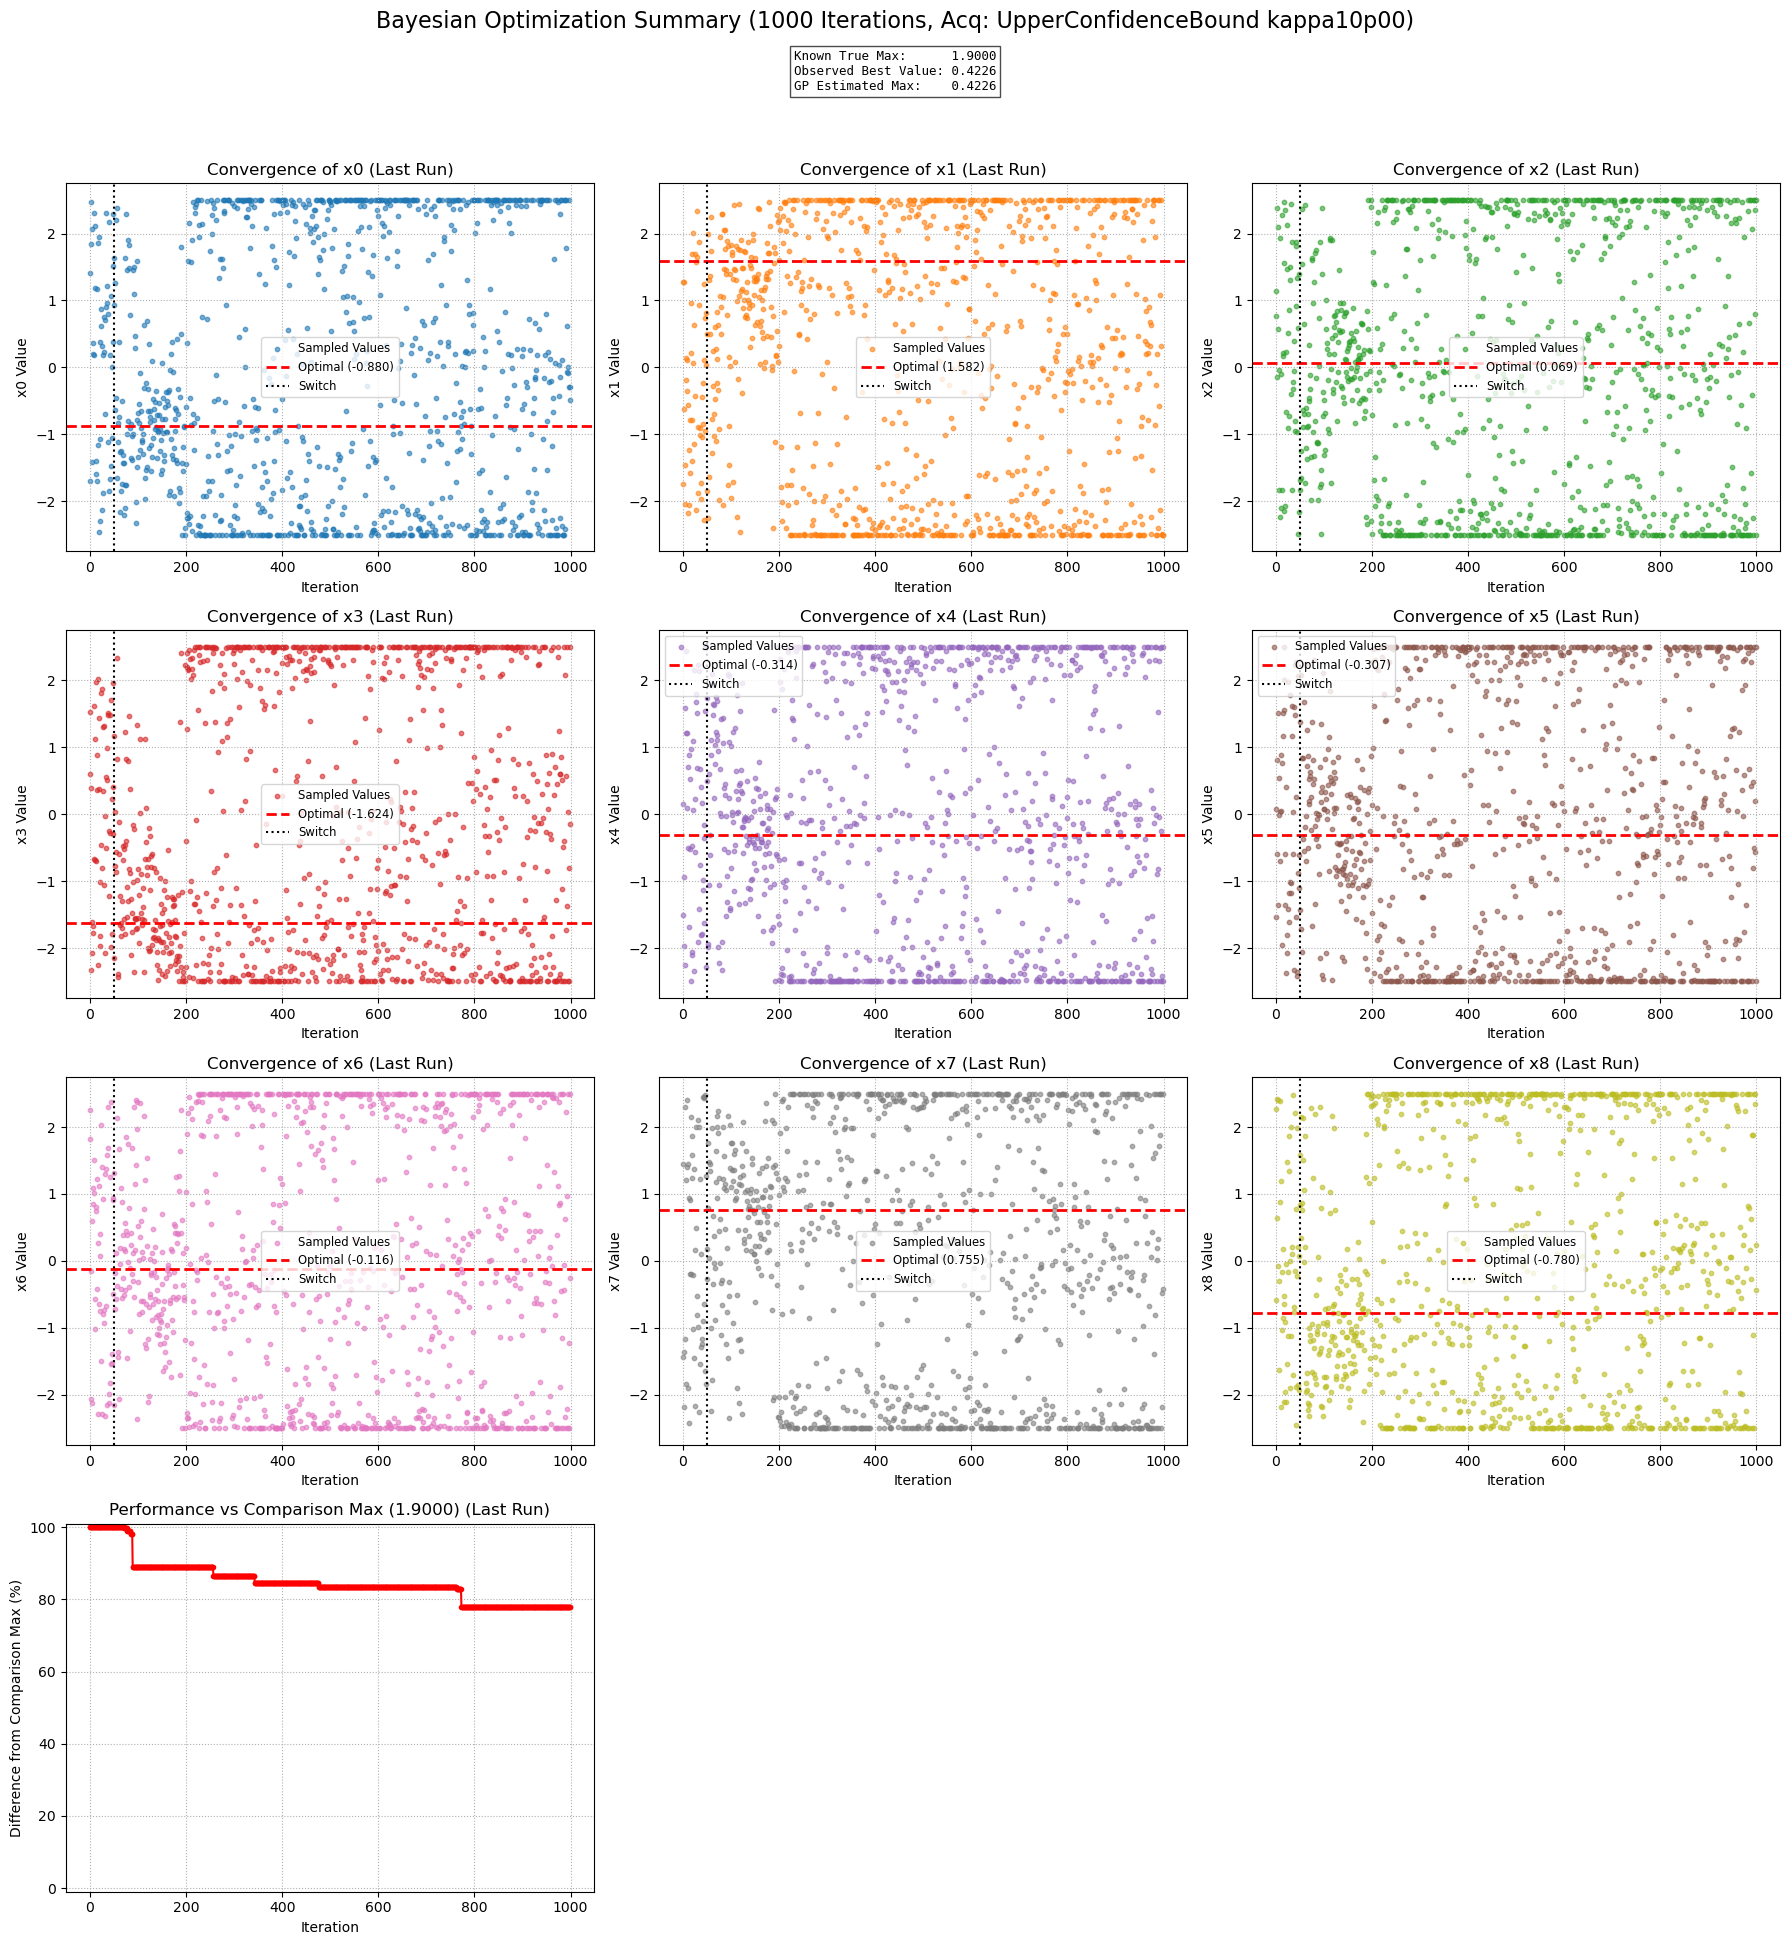

--- 5D Multi-Peak Known Max Experiment Complete ---


In [38]:
# 1. Define Parameters
dim_5d = 9
n_peaks_5d = 6
amp_global_5d = 1.9
amp_local_5d = 0.6
alpha_global_5d = 2.0
alpha_local_5d = 1.0
lower_5d = -2.5
upper_5d = 2.5
noise_5d = 0.0 # Ensure noise is zero
func_seed = 999

# 2. Generate the 5D function
func_5d, pbounds_5d, peaks_info_5d = generate_multi_peak_gaussian(
    dim=dim_5d,
    n_peaks=n_peaks_5d,
    amplitude_global=amp_global_5d,
    amplitude_local=amp_local_5d,
    alpha_global=alpha_global_5d,
    alpha_local=alpha_local_5d,
    lower=lower_5d,
    upper=upper_5d,
    noise=noise_5d, # Pass zero noise
    random_state=func_seed
)
print(f"Generated 5D function: {func_5d.__name__}")

# 3. Calculate the Precise Deterministic Maximum
shifts_arr = peaks_info_5d['shifts']
global_peak_shift = shifts_arr[0] # s0
deterministic_max_value = amp_global_5d # Contribution from global peak at its center

# Add contributions from local peaks at the global peak's location
for i in range(1, n_peaks_5d):
    local_peak_shift = shifts_arr[i]
    distance_sq = np.sum((global_peak_shift - local_peak_shift)**2)
    deterministic_max_value += amp_local_5d * np.exp(-alpha_local_5d * distance_sq)

print(f"Calculated Deterministic Max Value: {deterministic_max_value:.6f}")

# 4. Instantiate Optimizer with Known Max
optimizer_5d_known = BayesOptimizer(
    func=func_5d,
    pbounds=pbounds_5d,
    known_true_max=deterministic_max_value, # Pass the calculated value
    early_stopping_threshold=0.05, # Can use a tighter threshold now
    early_stopping_patience=2,
    verbose=True,
    plot_dir="toy_bayes"
)

# 5. Define Acquisition Function
acquisition_func_5d = UpperConfidenceBound(kappa=10.0)

# 6. Run the Experiment
print(f"\n--- Running Single {dim_5d}D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---")
single_run_data_5d = optimizer_5d_known.run_experiment(
    acquisition_fn=acquisition_func_5d,
    n_random=50,
    n_acq_max=950,
    approx_max_samples=10000, # Ignored, but still needs a value
    plot_summary=True,
    save_plot=True
)
print("--- 5D Multi-Peak Known Max Experiment Complete ---")

### Alpha Ratio 3:1

Generated 5D function: multiPeakGauss_d5_p6_ag1p5_al0p6_alphag3p0_alphal1p0_n0.00
Calculated Deterministic Max Value: 1.665300

--- Running Single 5D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---
Using known true maximum for comparison: 1.665300

Starting single optimization run: 50 random, max 950 acquisition steps.
Using Acquisition Function: ExpectedImprovement (xi0p10)


Random Exploration:   0%|          | 0/50 [00:00<?, ?it/s]

Acquisition Phase :   0%|          | 0/950 [00:00<?, ?it/s]


--- Single Run Finished ---
Optimization stopped early after 907 iterations.
Best value found (Observed): 1.600857
Best value found (GP Max):   1.600857
Best parameters found: {'x0': 1.4049671802333397, 'x1': -1.6619274014572105, 'x2': 1.1249907938226604, 'x3': 1.3446929320565952, 'x4': -1.7141943001721187}
Difference from Known True Max (1.665300): 0.064443 (3.8697%)
---------------------------
Summary plot saved to toy_bayes/bayesopt_summary_multiPeakGauss_d5_p6_ag1p5_al0p6_alphag3p0_alphal1p0_n0.00_d5_ExpectedImprovement_xi0p10_r50_a950_i907_noseed.png


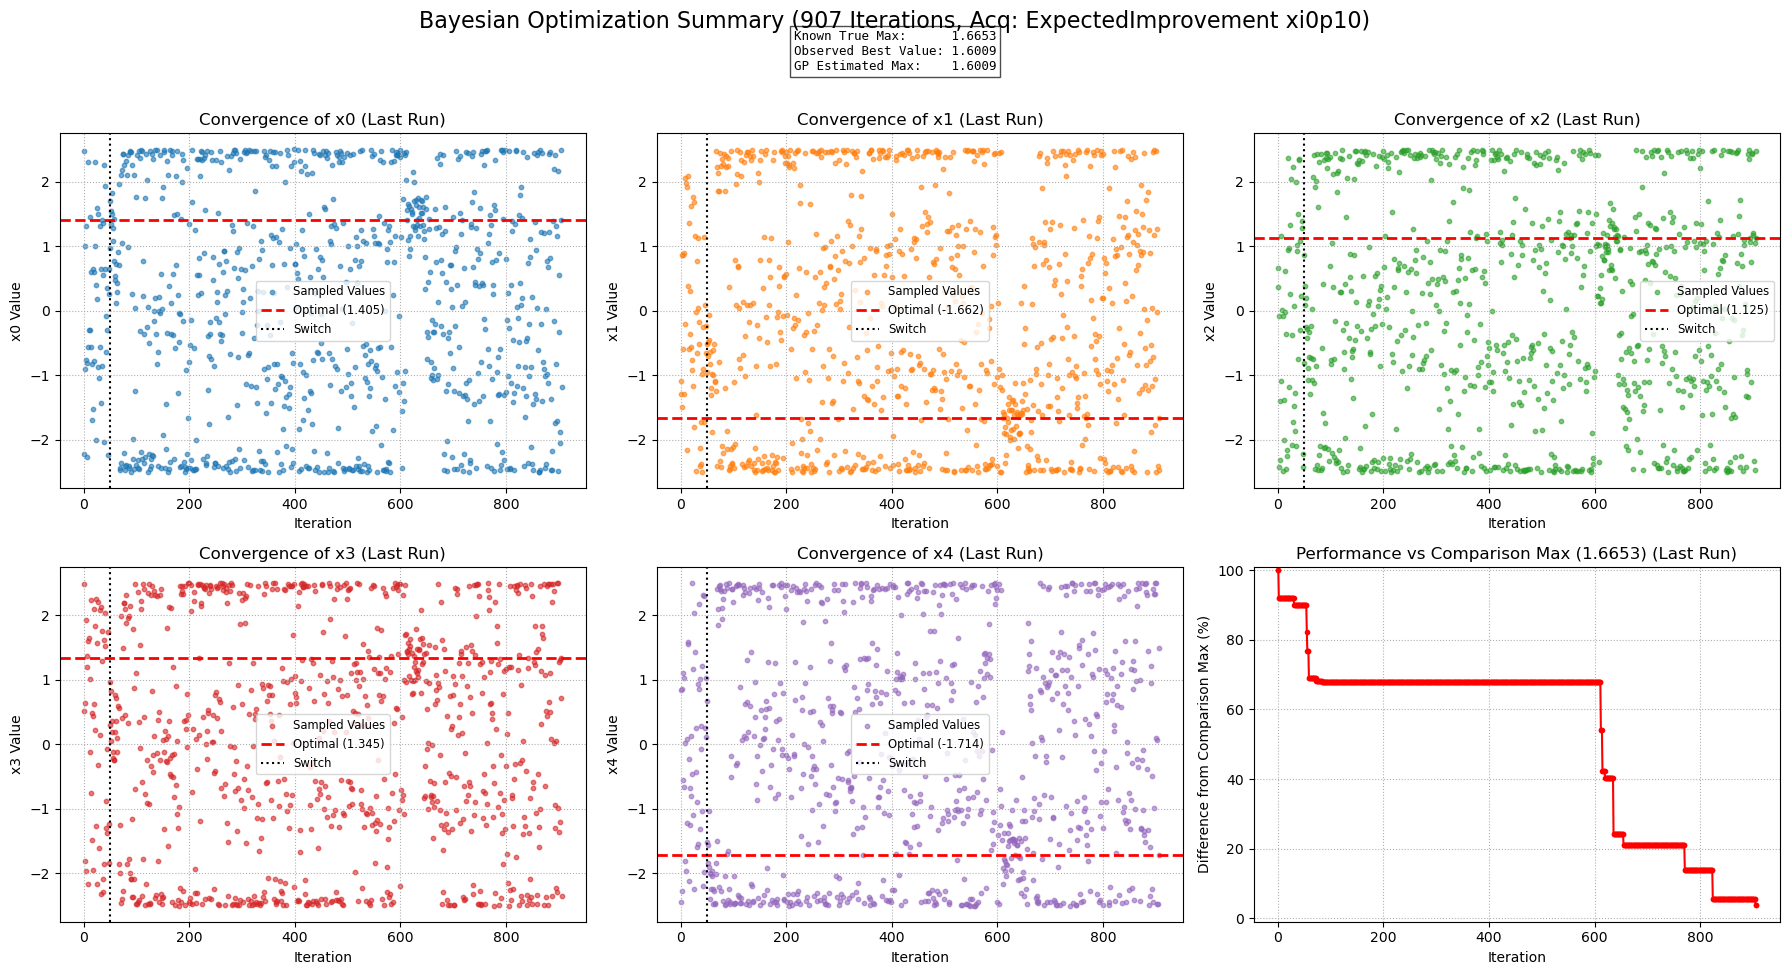

--- 5D Multi-Peak Known Max Experiment Complete ---


In [25]:
# 1. Define Parameters
dim_5d = 5
n_peaks_5d = 6
amp_global_5d = 1.5
amp_local_5d = 0.6
alpha_global_5d = 3.0
alpha_local_5d = 1.0
lower_5d = -2.5
upper_5d = 2.5
noise_5d = 0.0 # Ensure noise is zero
func_seed = 999

# 2. Generate the 5D function
func_5d, pbounds_5d, peaks_info_5d = generate_multi_peak_gaussian(
    dim=dim_5d,
    n_peaks=n_peaks_5d,
    amplitude_global=amp_global_5d,
    amplitude_local=amp_local_5d,
    alpha_global=alpha_global_5d,
    alpha_local=alpha_local_5d,
    lower=lower_5d,
    upper=upper_5d,
    noise=noise_5d, # Pass zero noise
    random_state=func_seed
)
print(f"Generated 5D function: {func_5d.__name__}")

# 3. Calculate the Precise Deterministic Maximum
shifts_arr = peaks_info_5d['shifts']
global_peak_shift = shifts_arr[0] # s0
deterministic_max_value = amp_global_5d # Contribution from global peak at its center

# Add contributions from local peaks at the global peak's location
for i in range(1, n_peaks_5d):
    local_peak_shift = shifts_arr[i]
    distance_sq = np.sum((global_peak_shift - local_peak_shift)**2)
    deterministic_max_value += amp_local_5d * np.exp(-alpha_local_5d * distance_sq)

print(f"Calculated Deterministic Max Value: {deterministic_max_value:.6f}")

# 4. Instantiate Optimizer with Known Max
optimizer_5d_known = BayesOptimizer(
    func=func_5d,
    pbounds=pbounds_5d,
    known_true_max=deterministic_max_value, # Pass the calculated value
    early_stopping_threshold=0.05, # Can use a tighter threshold now
    early_stopping_patience=2,
    verbose=True,
    plot_dir="toy_bayes"
)

# 5. Define Acquisition Function
acquisition_func_5d = ExpectedImprovement(xi=0.1)

# 6. Run the Experiment
print(f"\n--- Running Single {dim_5d}D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---")
single_run_data_5d = optimizer_5d_known.run_experiment(
    acquisition_fn=acquisition_func_5d,
    n_random=50,
    n_acq_max=950,
    approx_max_samples=10000, # Ignored, but still needs a value
    plot_summary=True,
    save_plot=True
)
print("--- 5D Multi-Peak Known Max Experiment Complete ---")

### Alpha Ratio 5:1

Generated 5D function: multiPeakGauss_d5_p6_ag1p5_al0p6_alphag5p0_alphal1p0_n0.00
Calculated Deterministic Max Value: 1.665300

--- Running Single 5D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---
Using known true maximum for comparison: 1.665300

Starting single optimization run: 50 random, max 950 acquisition steps.
Using Acquisition Function: ExpectedImprovement (xi0p10)


Random Exploration:   0%|          | 0/50 [00:00<?, ?it/s]

Acquisition Phase :   0%|          | 0/950 [00:00<?, ?it/s]


--- Single Run Finished ---
Optimization finished after 1000 iterations.
Best value found (Observed): 0.600844
Best value found (GP Max):   0.600844
Best parameters found: {'x0': -1.0618677015421163, 'x1': -2.261554977892829, 'x2': -1.5160024525046594, 'x3': -1.0441806899865118, 'x4': 1.1678892452306477}
Difference from Known True Max (1.665300): 1.064455 (63.9197%)
---------------------------
Summary plot saved to toy_bayes/bayesopt_summary_multiPeakGauss_d5_p6_ag1p5_al0p6_alphag5p0_alphal1p0_n0.00_d5_ExpectedImprovement_xi0p10_r50_a950_i1000_noseed.png


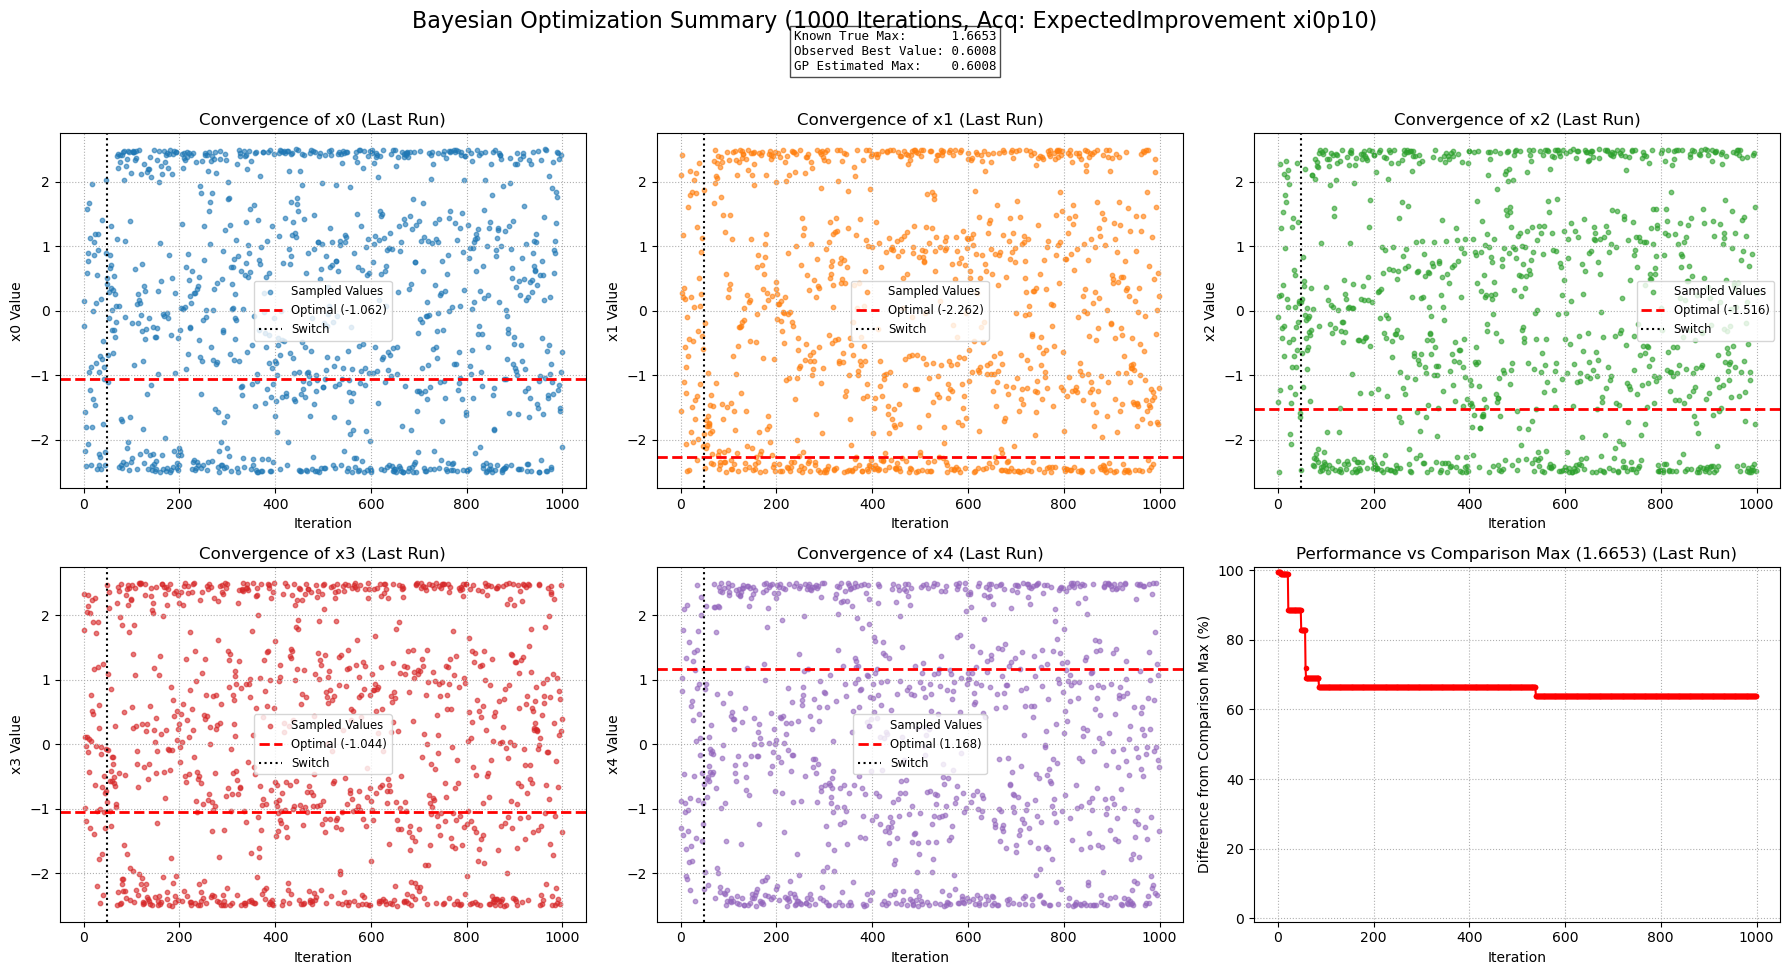

--- 5D Multi-Peak Known Max Experiment Complete ---


In [26]:
# 1. Define Parameters
dim_5d = 5
n_peaks_5d = 6
amp_global_5d = 1.5
amp_local_5d = 0.6
alpha_global_5d = 5.0
alpha_local_5d = 1.0
lower_5d = -2.5
upper_5d = 2.5
noise_5d = 0.0 # Ensure noise is zero
func_seed = 999

# 2. Generate the 5D function
func_5d, pbounds_5d, peaks_info_5d = generate_multi_peak_gaussian(
    dim=dim_5d,
    n_peaks=n_peaks_5d,
    amplitude_global=amp_global_5d,
    amplitude_local=amp_local_5d,
    alpha_global=alpha_global_5d,
    alpha_local=alpha_local_5d,
    lower=lower_5d,
    upper=upper_5d,
    noise=noise_5d, # Pass zero noise
    random_state=func_seed
)
print(f"Generated 5D function: {func_5d.__name__}")

# 3. Calculate the Precise Deterministic Maximum
shifts_arr = peaks_info_5d['shifts']
global_peak_shift = shifts_arr[0] # s0
deterministic_max_value = amp_global_5d # Contribution from global peak at its center

# Add contributions from local peaks at the global peak's location
for i in range(1, n_peaks_5d):
    local_peak_shift = shifts_arr[i]
    distance_sq = np.sum((global_peak_shift - local_peak_shift)**2)
    deterministic_max_value += amp_local_5d * np.exp(-alpha_local_5d * distance_sq)

print(f"Calculated Deterministic Max Value: {deterministic_max_value:.6f}")

# 4. Instantiate Optimizer with Known Max
optimizer_5d_known = BayesOptimizer(
    func=func_5d,
    pbounds=pbounds_5d,
    known_true_max=deterministic_max_value, # Pass the calculated value
    early_stopping_threshold=0.05, # Can use a tighter threshold now
    early_stopping_patience=2,
    verbose=True,
    plot_dir="toy_bayes"
)

# 5. Define Acquisition Function
acquisition_func_5d = ExpectedImprovement(xi=0.1)

# 6. Run the Experiment
print(f"\n--- Running Single {dim_5d}D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---")
single_run_data_5d = optimizer_5d_known.run_experiment(
    acquisition_fn=acquisition_func_5d,
    n_random=50,
    n_acq_max=950,
    approx_max_samples=10000, # Ignored, but still needs a value
    plot_summary=True,
    save_plot=True
)
print("--- 5D Multi-Peak Known Max Experiment Complete ---")

# Xi = 0.5

Generated 5D function: multiPeakGauss_d5_p6_ag1p5_al0p6_alphag2p0_alphal1p0_n0.00
Calculated Deterministic Max Value: 1.665300

--- Running Single 5D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---
Using known true maximum for comparison: 1.665300

Starting single optimization run: 50 random, max 950 acquisition steps.
Using Acquisition Function: ExpectedImprovement (xi0p50)


Random Exploration:   0%|          | 0/50 [00:00<?, ?it/s]

Acquisition Phase :   0%|          | 0/950 [00:00<?, ?it/s]


--- Single Run Finished ---
Optimization stopped early after 412 iterations.
Best value found (Observed): 1.592182
Best value found (GP Max):   1.592182
Best parameters found: {'x0': 1.5245014845024563, 'x1': -1.707570534661031, 'x2': 0.9243476614782214, 'x3': 1.3740665756594128, 'x4': -1.683654938650413}
Difference from Known True Max (1.665300): 0.073118 (4.3907%)
---------------------------
Summary plot saved to toy_bayes/bayesopt_summary_multiPeakGauss_d5_p6_ag1p5_al0p6_alphag2p0_alphal1p0_n0.00_d5_ExpectedImprovement_xi0p50_r50_a950_i412_noseed.png


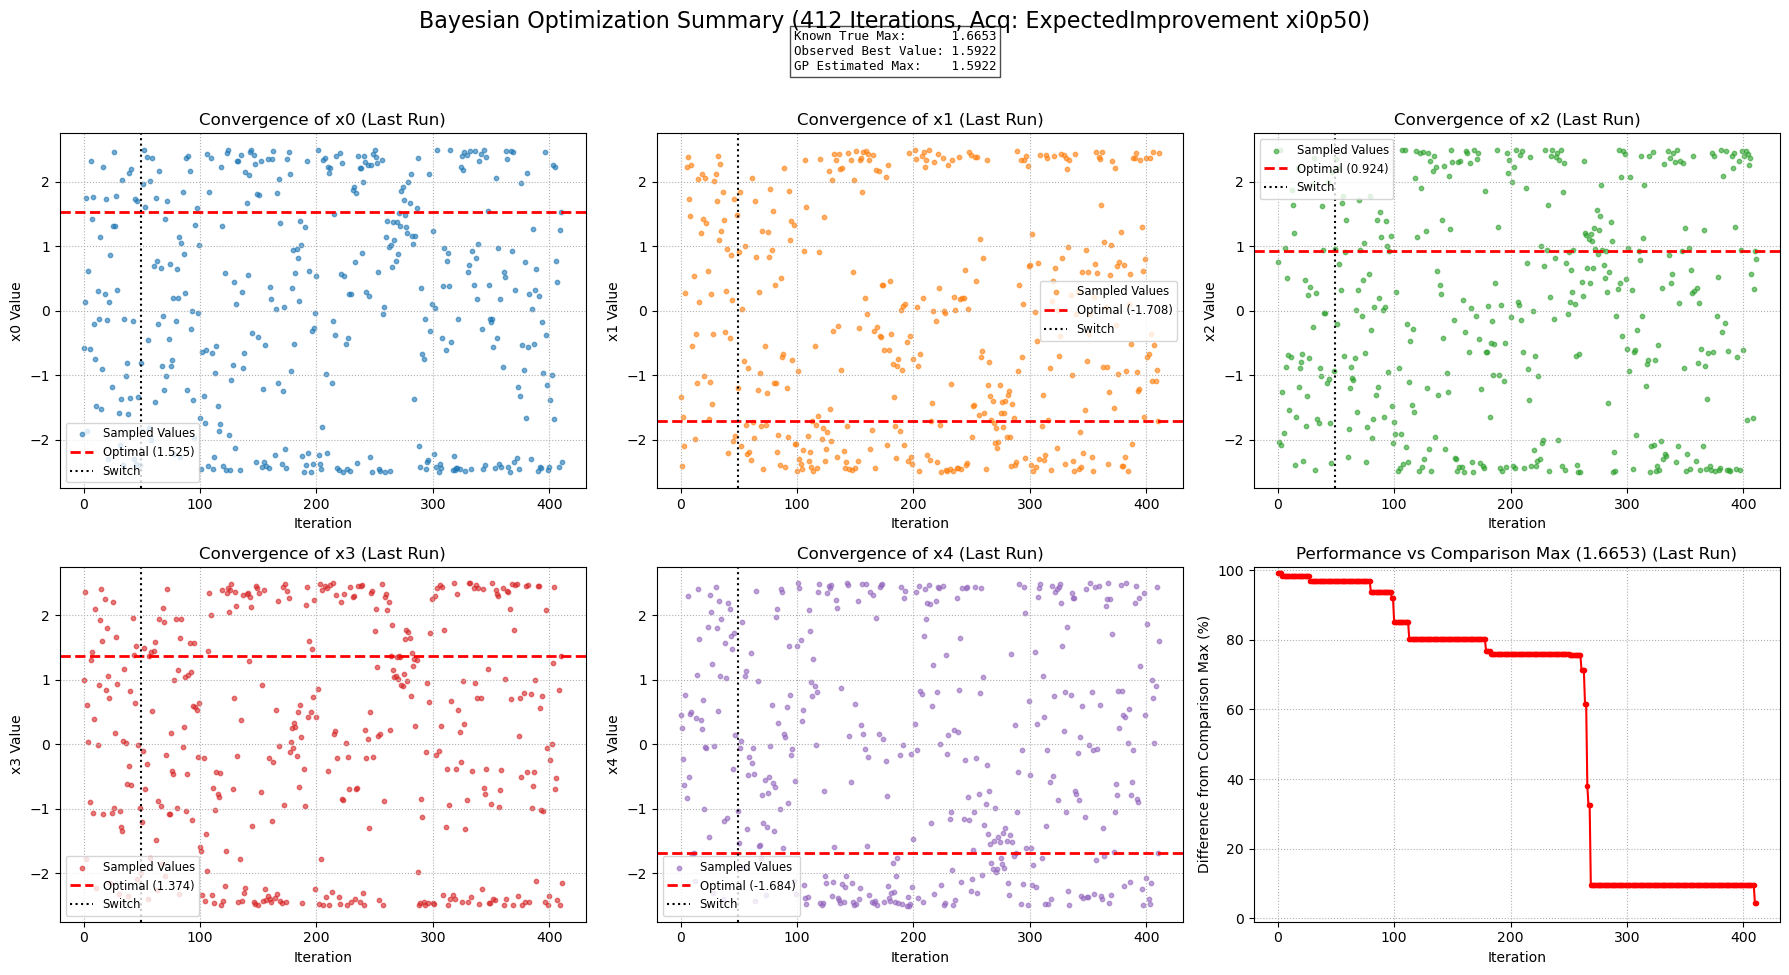

--- 5D Multi-Peak Known Max Experiment Complete ---


In [27]:
# 1. Define Parameters
dim_5d = 5
n_peaks_5d = 6
amp_global_5d = 1.5
amp_local_5d = 0.6
alpha_global_5d = 2.0
alpha_local_5d = 1.0
lower_5d = -2.5
upper_5d = 2.5
noise_5d = 0.0 # Ensure noise is zero
func_seed = 999

# 2. Generate the 5D function
func_5d, pbounds_5d, peaks_info_5d = generate_multi_peak_gaussian(
    dim=dim_5d,
    n_peaks=n_peaks_5d,
    amplitude_global=amp_global_5d,
    amplitude_local=amp_local_5d,
    alpha_global=alpha_global_5d,
    alpha_local=alpha_local_5d,
    lower=lower_5d,
    upper=upper_5d,
    noise=noise_5d, # Pass zero noise
    random_state=func_seed
)
print(f"Generated 5D function: {func_5d.__name__}")

# 3. Calculate the Precise Deterministic Maximum
shifts_arr = peaks_info_5d['shifts']
global_peak_shift = shifts_arr[0] # s0
deterministic_max_value = amp_global_5d # Contribution from global peak at its center

# Add contributions from local peaks at the global peak's location
for i in range(1, n_peaks_5d):
    local_peak_shift = shifts_arr[i]
    distance_sq = np.sum((global_peak_shift - local_peak_shift)**2)
    deterministic_max_value += amp_local_5d * np.exp(-alpha_local_5d * distance_sq)

print(f"Calculated Deterministic Max Value: {deterministic_max_value:.6f}")

# 4. Instantiate Optimizer with Known Max
optimizer_5d_known = BayesOptimizer(
    func=func_5d,
    pbounds=pbounds_5d,
    known_true_max=deterministic_max_value, # Pass the calculated value
    early_stopping_threshold=0.05, # Can use a tighter threshold now
    early_stopping_patience=2,
    verbose=True,
    plot_dir="toy_bayes"
)

# 5. Define Acquisition Function
acquisition_func_5d = ExpectedImprovement(xi=0.5)

# 6. Run the Experiment
print(f"\n--- Running Single {dim_5d}D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---")
single_run_data_5d = optimizer_5d_known.run_experiment(
    acquisition_fn=acquisition_func_5d,
    n_random=50,
    n_acq_max=950,
    approx_max_samples=10000, # Ignored, but still needs a value
    plot_summary=True,
    save_plot=True
)
print("--- 5D Multi-Peak Known Max Experiment Complete ---")

Generated 5D function: multiPeakGauss_d5_p6_ag1p5_al0p6_alphag3p0_alphal1p0_n0.00
Calculated Deterministic Max Value: 1.665300

--- Running Single 5D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---
Using known true maximum for comparison: 1.665300

Starting single optimization run: 50 random, max 950 acquisition steps.
Using Acquisition Function: ExpectedImprovement (xi0p50)


Random Exploration:   0%|          | 0/50 [00:00<?, ?it/s]

Acquisition Phase :   0%|          | 0/950 [00:00<?, ?it/s]


--- Single Run Finished ---
Optimization finished after 1000 iterations.
Best value found (Observed): 1.393896
Best value found (GP Max):   1.393896
Best parameters found: {'x0': 1.5410868402778788, 'x1': -1.7056850265537866, 'x2': 1.1010078422959169, 'x3': 1.0793452606820115, 'x4': -1.6949755656345156}
Difference from Known True Max (1.665300): 0.271404 (16.2976%)
---------------------------
Summary plot saved to toy_bayes/bayesopt_summary_multiPeakGauss_d5_p6_ag1p5_al0p6_alphag3p0_alphal1p0_n0.00_d5_ExpectedImprovement_xi0p50_r50_a950_i1000_noseed.png


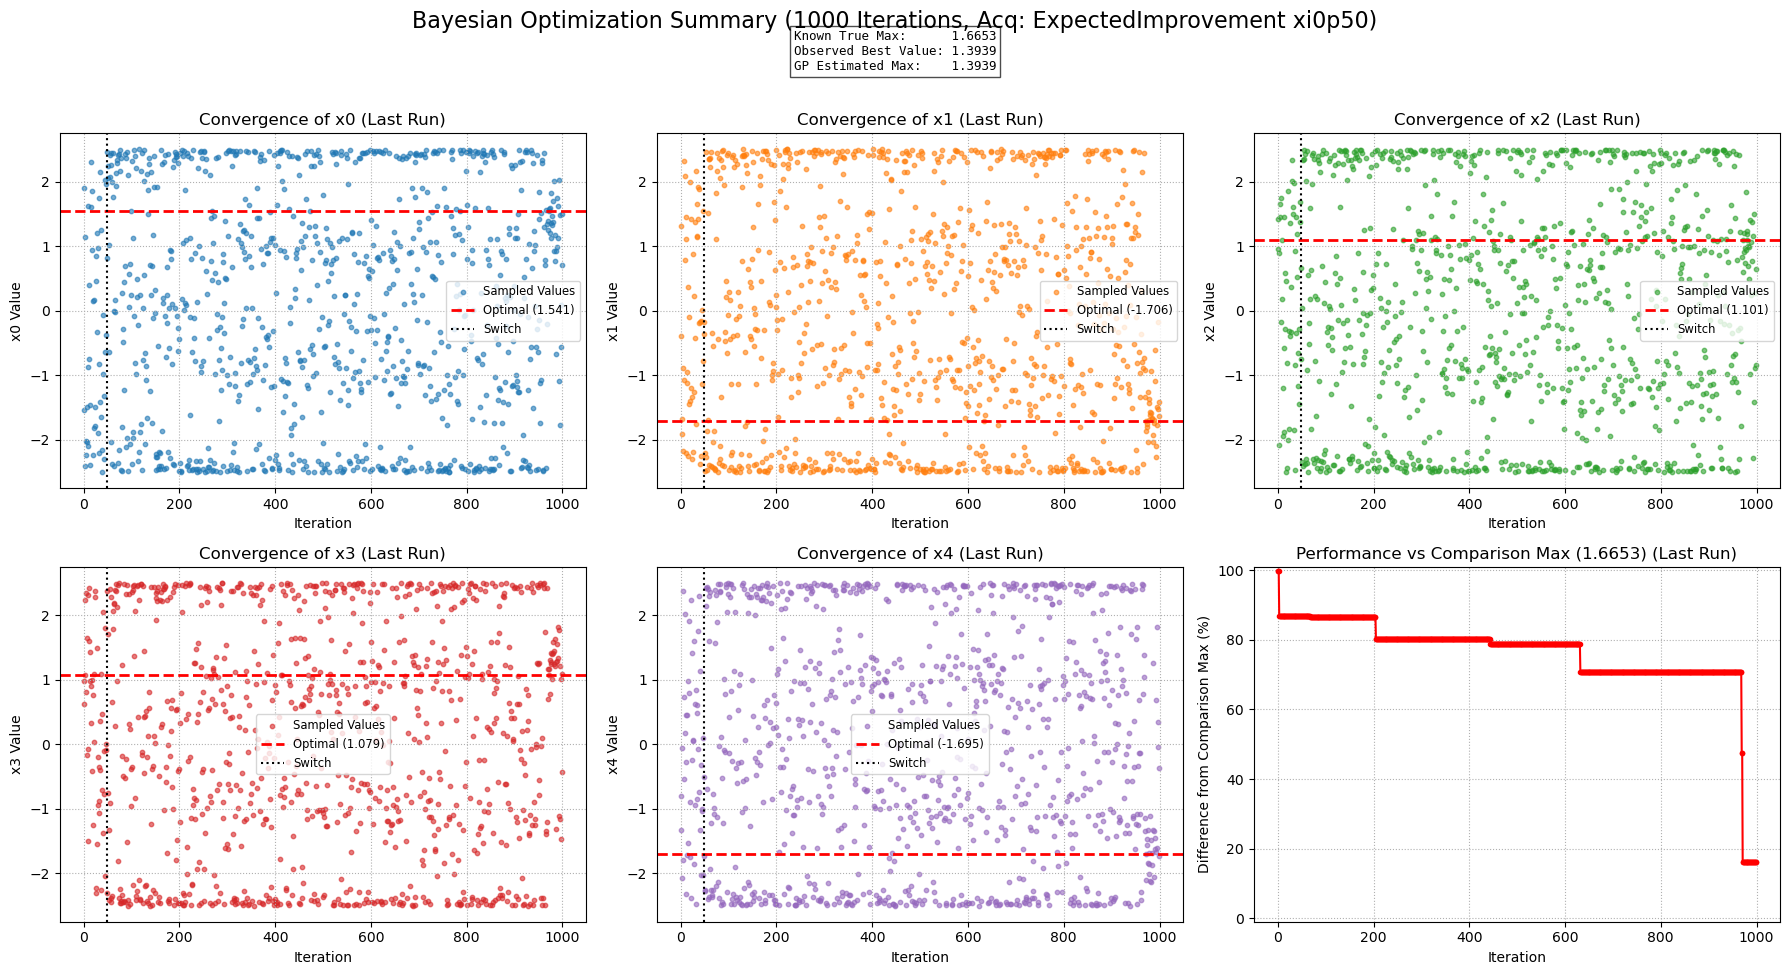

--- 5D Multi-Peak Known Max Experiment Complete ---


In [28]:
# 1. Define Parameters
dim_5d = 5
n_peaks_5d = 6
amp_global_5d = 1.5
amp_local_5d = 0.6
alpha_global_5d = 3.0
alpha_local_5d = 1.0
lower_5d = -2.5
upper_5d = 2.5
noise_5d = 0.0 # Ensure noise is zero
func_seed = 999

# 2. Generate the 5D function
func_5d, pbounds_5d, peaks_info_5d = generate_multi_peak_gaussian(
    dim=dim_5d,
    n_peaks=n_peaks_5d,
    amplitude_global=amp_global_5d,
    amplitude_local=amp_local_5d,
    alpha_global=alpha_global_5d,
    alpha_local=alpha_local_5d,
    lower=lower_5d,
    upper=upper_5d,
    noise=noise_5d, # Pass zero noise
    random_state=func_seed
)
print(f"Generated 5D function: {func_5d.__name__}")

# 3. Calculate the Precise Deterministic Maximum
shifts_arr = peaks_info_5d['shifts']
global_peak_shift = shifts_arr[0] # s0
deterministic_max_value = amp_global_5d # Contribution from global peak at its center

# Add contributions from local peaks at the global peak's location
for i in range(1, n_peaks_5d):
    local_peak_shift = shifts_arr[i]
    distance_sq = np.sum((global_peak_shift - local_peak_shift)**2)
    deterministic_max_value += amp_local_5d * np.exp(-alpha_local_5d * distance_sq)

print(f"Calculated Deterministic Max Value: {deterministic_max_value:.6f}")

# 4. Instantiate Optimizer with Known Max
optimizer_5d_known = BayesOptimizer(
    func=func_5d,
    pbounds=pbounds_5d,
    known_true_max=deterministic_max_value, # Pass the calculated value
    early_stopping_threshold=0.05, # Can use a tighter threshold now
    early_stopping_patience=2,
    verbose=True,
    plot_dir="toy_bayes"
)

# 5. Define Acquisition Function
acquisition_func_5d = ExpectedImprovement(xi=0.5)

# 6. Run the Experiment
print(f"\n--- Running Single {dim_5d}D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---")
single_run_data_5d = optimizer_5d_known.run_experiment(
    acquisition_fn=acquisition_func_5d,
    n_random=50,
    n_acq_max=950,
    approx_max_samples=10000, # Ignored, but still needs a value
    plot_summary=True,
    save_plot=True
)
print("--- 5D Multi-Peak Known Max Experiment Complete ---")

Generated 5D function: multiPeakGauss_d5_p6_ag1p5_al0p6_alphag5p0_alphal1p0_n0.00
Calculated Deterministic Max Value: 1.665300

--- Running Single 5D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---
Using known true maximum for comparison: 1.665300

Starting single optimization run: 50 random, max 950 acquisition steps.
Using Acquisition Function: ExpectedImprovement (xi0p50)


Random Exploration:   0%|          | 0/50 [00:00<?, ?it/s]

Acquisition Phase :   0%|          | 0/950 [00:00<?, ?it/s]


--- Single Run Finished ---
Optimization finished after 1000 iterations.
Best value found (Observed): 0.533971
Best value found (GP Max):   0.533971
Best parameters found: {'x0': -0.8210670412976268, 'x1': -2.4412138616776806, 'x2': -1.7113696396934575, 'x3': -1.0900394365884791, 'x4': 1.2786381243672318}
Difference from Known True Max (1.665300): 1.131329 (67.9354%)
---------------------------
Summary plot saved to toy_bayes/bayesopt_summary_multiPeakGauss_d5_p6_ag1p5_al0p6_alphag5p0_alphal1p0_n0.00_d5_ExpectedImprovement_xi0p50_r50_a950_i1000_noseed.png


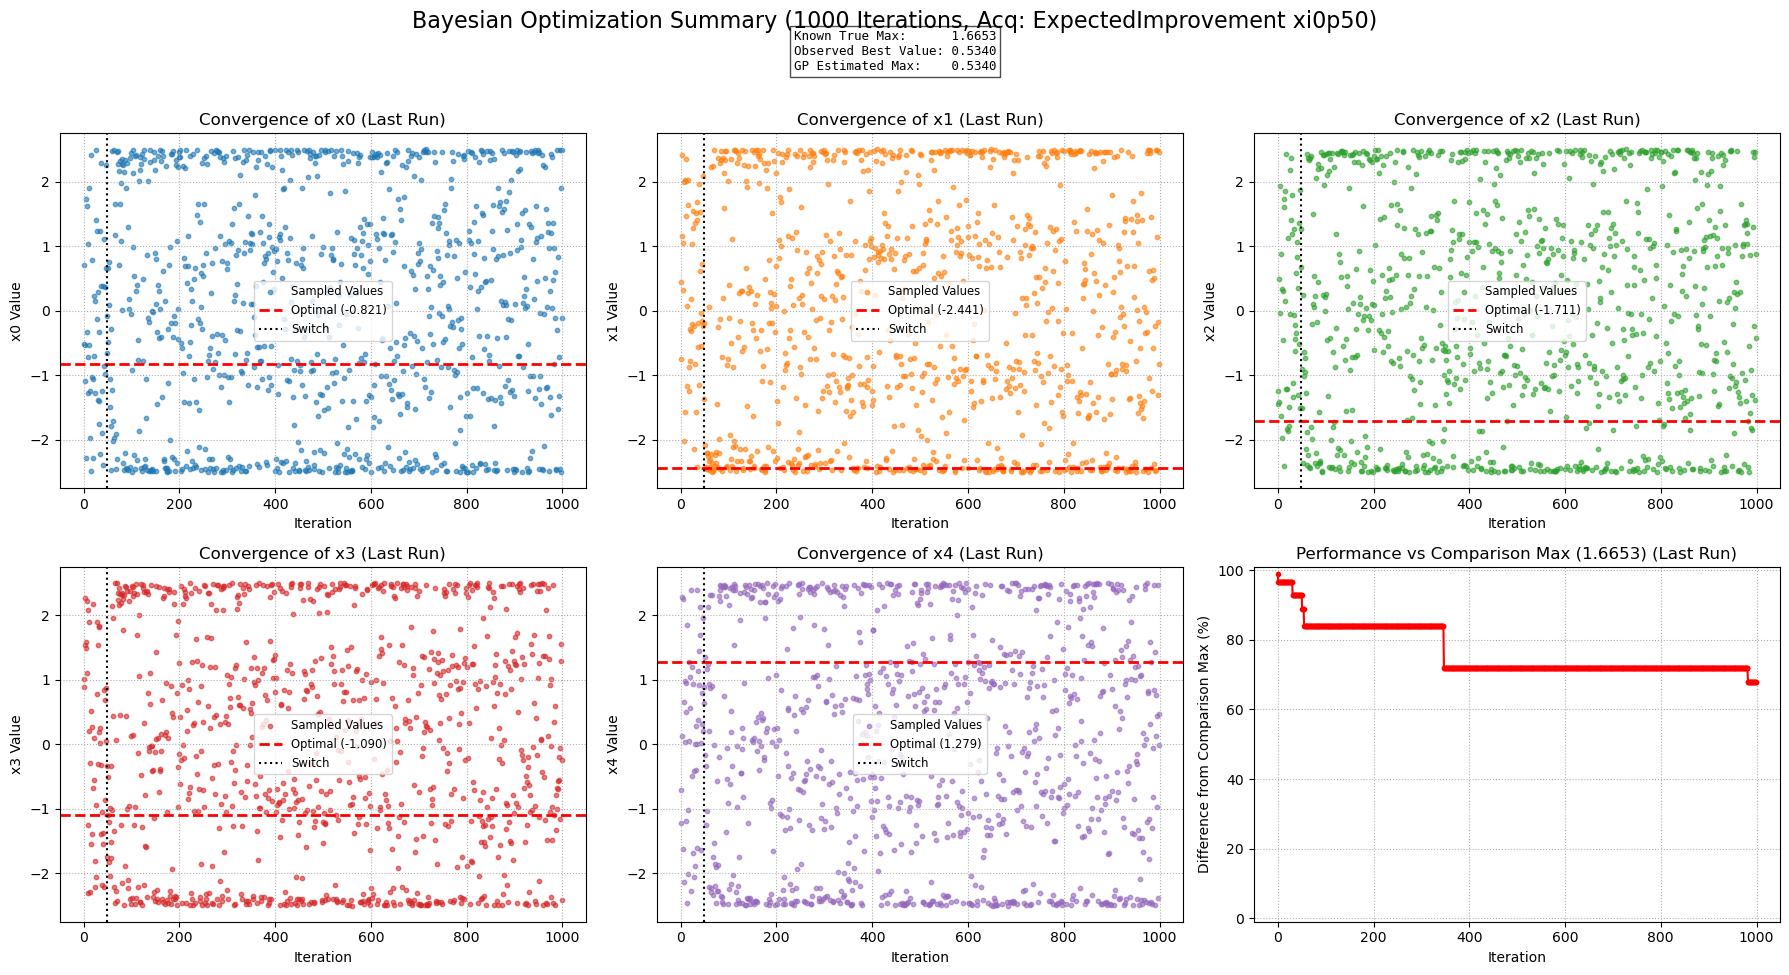

--- 5D Multi-Peak Known Max Experiment Complete ---


In [29]:
# 1. Define Parameters
dim_5d = 5
n_peaks_5d = 6
amp_global_5d = 1.5
amp_local_5d = 0.6
alpha_global_5d = 5.0
alpha_local_5d = 1.0
lower_5d = -2.5
upper_5d = 2.5
noise_5d = 0.0 # Ensure noise is zero
func_seed = 999

# 2. Generate the 5D function
func_5d, pbounds_5d, peaks_info_5d = generate_multi_peak_gaussian(
    dim=dim_5d,
    n_peaks=n_peaks_5d,
    amplitude_global=amp_global_5d,
    amplitude_local=amp_local_5d,
    alpha_global=alpha_global_5d,
    alpha_local=alpha_local_5d,
    lower=lower_5d,
    upper=upper_5d,
    noise=noise_5d, # Pass zero noise
    random_state=func_seed
)
print(f"Generated 5D function: {func_5d.__name__}")

# 3. Calculate the Precise Deterministic Maximum
shifts_arr = peaks_info_5d['shifts']
global_peak_shift = shifts_arr[0] # s0
deterministic_max_value = amp_global_5d # Contribution from global peak at its center

# Add contributions from local peaks at the global peak's location
for i in range(1, n_peaks_5d):
    local_peak_shift = shifts_arr[i]
    distance_sq = np.sum((global_peak_shift - local_peak_shift)**2)
    deterministic_max_value += amp_local_5d * np.exp(-alpha_local_5d * distance_sq)

print(f"Calculated Deterministic Max Value: {deterministic_max_value:.6f}")

# 4. Instantiate Optimizer with Known Max
optimizer_5d_known = BayesOptimizer(
    func=func_5d,
    pbounds=pbounds_5d,
    known_true_max=deterministic_max_value, # Pass the calculated value
    early_stopping_threshold=0.05, # Can use a tighter threshold now
    early_stopping_patience=2,
    verbose=True,
    plot_dir="toy_bayes"
)

# 5. Define Acquisition Function
acquisition_func_5d = ExpectedImprovement(xi=0.5)

# 6. Run the Experiment
print(f"\n--- Running Single {dim_5d}D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---")
single_run_data_5d = optimizer_5d_known.run_experiment(
    acquisition_fn=acquisition_func_5d,
    n_random=50,
    n_acq_max=950,
    approx_max_samples=10000, # Ignored, but still needs a value
    plot_summary=True,
    save_plot=True
)
print("--- 5D Multi-Peak Known Max Experiment Complete ---")

# Xi = 0.9

Generated 5D function: multiPeakGauss_d5_p6_ag1p5_al0p6_alphag2p0_alphal1p0_n0.00
Calculated Deterministic Max Value: 1.665300

--- Running Single 5D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---
Using known true maximum for comparison: 1.665300

Starting single optimization run: 50 random, max 950 acquisition steps.
Using Acquisition Function: ExpectedImprovement (xi0p90)


Random Exploration:   0%|          | 0/50 [00:00<?, ?it/s]

Acquisition Phase :   0%|          | 0/950 [00:00<?, ?it/s]


--- Single Run Finished ---
Optimization finished after 1000 iterations.
Best value found (Observed): 0.398266
Best value found (GP Max):   0.398266
Best parameters found: {'x0': -1.0925079645009128, 'x1': -2.0627035129509808, 'x2': -1.8288302855896728, 'x3': -0.5268406582608148, 'x4': 1.3180228561690899}
Difference from Known True Max (1.665300): 1.267033 (76.0844%)
---------------------------
Summary plot saved to toy_bayes/bayesopt_summary_multiPeakGauss_d5_p6_ag1p5_al0p6_alphag2p0_alphal1p0_n0.00_d5_ExpectedImprovement_xi0p90_r50_a950_i1000_noseed.png


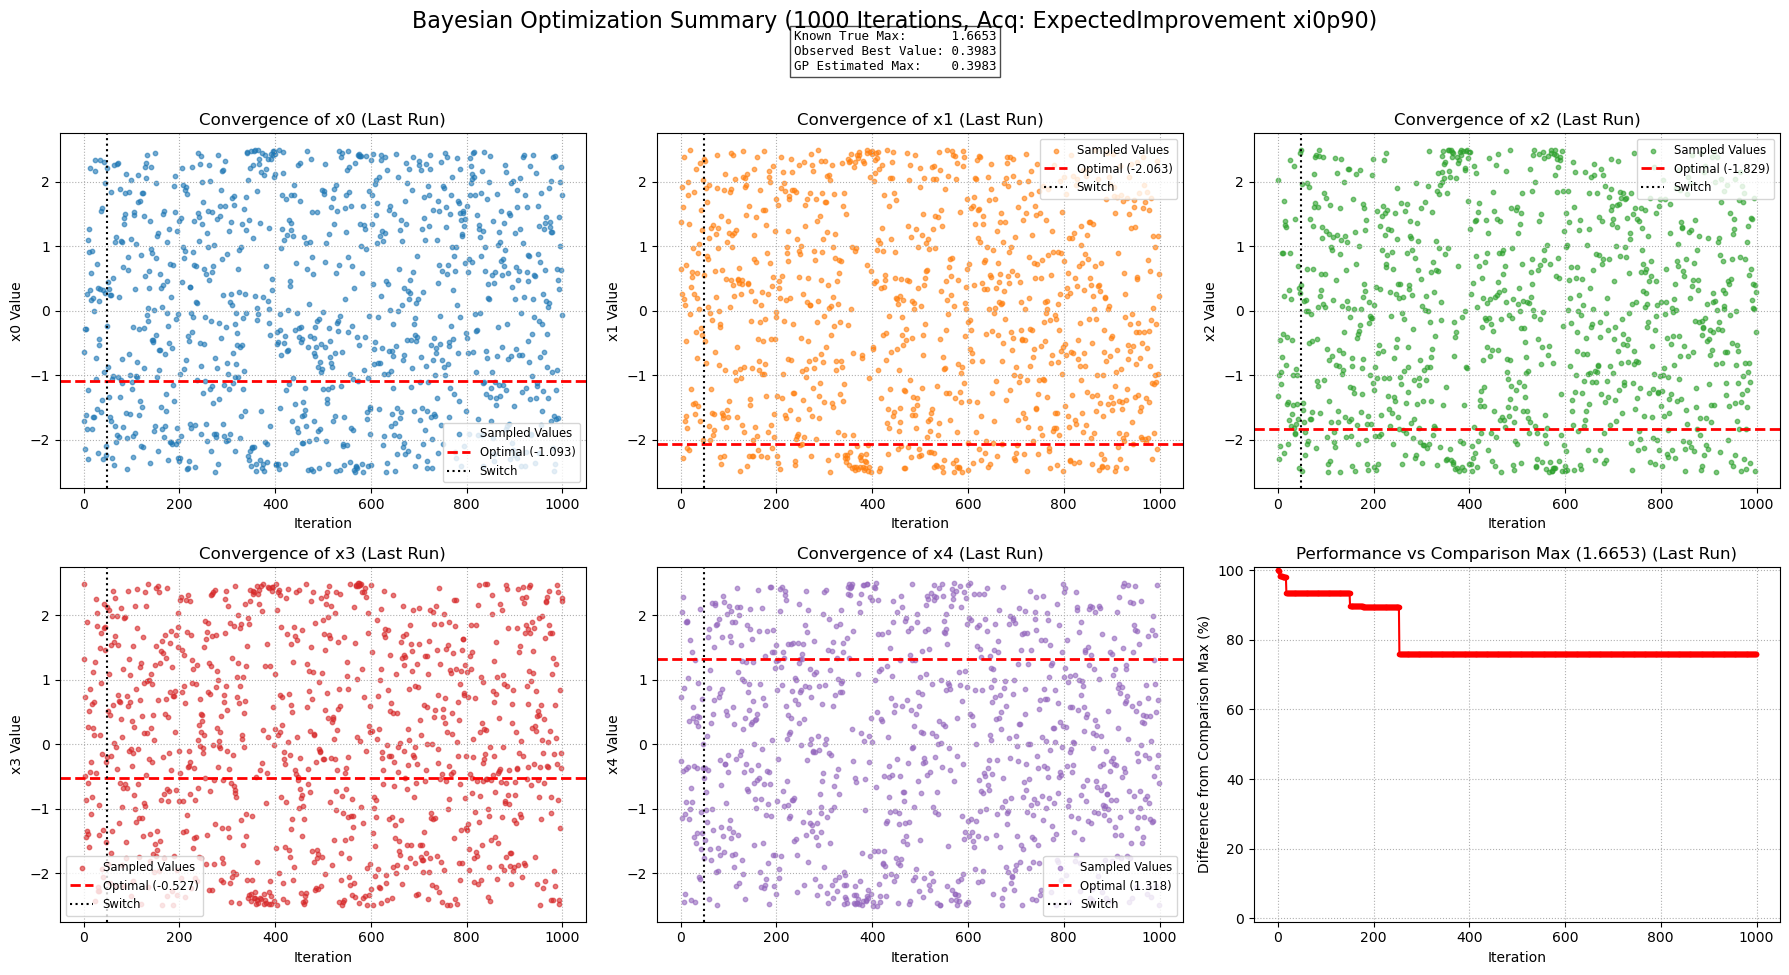

--- 5D Multi-Peak Known Max Experiment Complete ---


In [30]:
# 1. Define Parameters
dim_5d = 5
n_peaks_5d = 6
amp_global_5d = 1.5
amp_local_5d = 0.6
alpha_global_5d = 2.0
alpha_local_5d = 1.0
lower_5d = -2.5
upper_5d = 2.5
noise_5d = 0.0 # Ensure noise is zero
func_seed = 999

# 2. Generate the 5D function
func_5d, pbounds_5d, peaks_info_5d = generate_multi_peak_gaussian(
    dim=dim_5d,
    n_peaks=n_peaks_5d,
    amplitude_global=amp_global_5d,
    amplitude_local=amp_local_5d,
    alpha_global=alpha_global_5d,
    alpha_local=alpha_local_5d,
    lower=lower_5d,
    upper=upper_5d,
    noise=noise_5d, # Pass zero noise
    random_state=func_seed
)
print(f"Generated 5D function: {func_5d.__name__}")

# 3. Calculate the Precise Deterministic Maximum
shifts_arr = peaks_info_5d['shifts']
global_peak_shift = shifts_arr[0] # s0
deterministic_max_value = amp_global_5d # Contribution from global peak at its center

# Add contributions from local peaks at the global peak's location
for i in range(1, n_peaks_5d):
    local_peak_shift = shifts_arr[i]
    distance_sq = np.sum((global_peak_shift - local_peak_shift)**2)
    deterministic_max_value += amp_local_5d * np.exp(-alpha_local_5d * distance_sq)

print(f"Calculated Deterministic Max Value: {deterministic_max_value:.6f}")

# 4. Instantiate Optimizer with Known Max
optimizer_5d_known = BayesOptimizer(
    func=func_5d,
    pbounds=pbounds_5d,
    known_true_max=deterministic_max_value, # Pass the calculated value
    early_stopping_threshold=0.05, # Can use a tighter threshold now
    early_stopping_patience=2,
    verbose=True,
    plot_dir="toy_bayes"
)

# 5. Define Acquisition Function
acquisition_func_5d = ExpectedImprovement(xi=0.9)

# 6. Run the Experiment
print(f"\n--- Running Single {dim_5d}D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---")
single_run_data_5d = optimizer_5d_known.run_experiment(
    acquisition_fn=acquisition_func_5d,
    n_random=50,
    n_acq_max=950,
    approx_max_samples=10000, # Ignored, but still needs a value
    plot_summary=True,
    save_plot=True
)
print("--- 5D Multi-Peak Known Max Experiment Complete ---")

Generated 5D function: multiPeakGauss_d5_p6_ag1p5_al0p6_alphag3p0_alphal1p0_n0.00
Calculated Deterministic Max Value: 1.665300

--- Running Single 5D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---
Using known true maximum for comparison: 1.665300

Starting single optimization run: 50 random, max 950 acquisition steps.
Using Acquisition Function: ExpectedImprovement (xi0p90)


Random Exploration:   0%|          | 0/50 [00:00<?, ?it/s]

Acquisition Phase :   0%|          | 0/950 [00:00<?, ?it/s]


--- Single Run Finished ---
Optimization finished after 1000 iterations.
Best value found (Observed): 0.383091
Best value found (GP Max):   0.383091
Best parameters found: {'x0': -0.6566582737447396, 'x1': -2.3751555185172424, 'x2': -1.6624885982984945, 'x3': -1.1624230205889634, 'x4': 0.6044744882271763}
Difference from Known True Max (1.665300): 1.282209 (76.9957%)
---------------------------
Summary plot saved to toy_bayes/bayesopt_summary_multiPeakGauss_d5_p6_ag1p5_al0p6_alphag3p0_alphal1p0_n0.00_d5_ExpectedImprovement_xi0p90_r50_a950_i1000_noseed.png


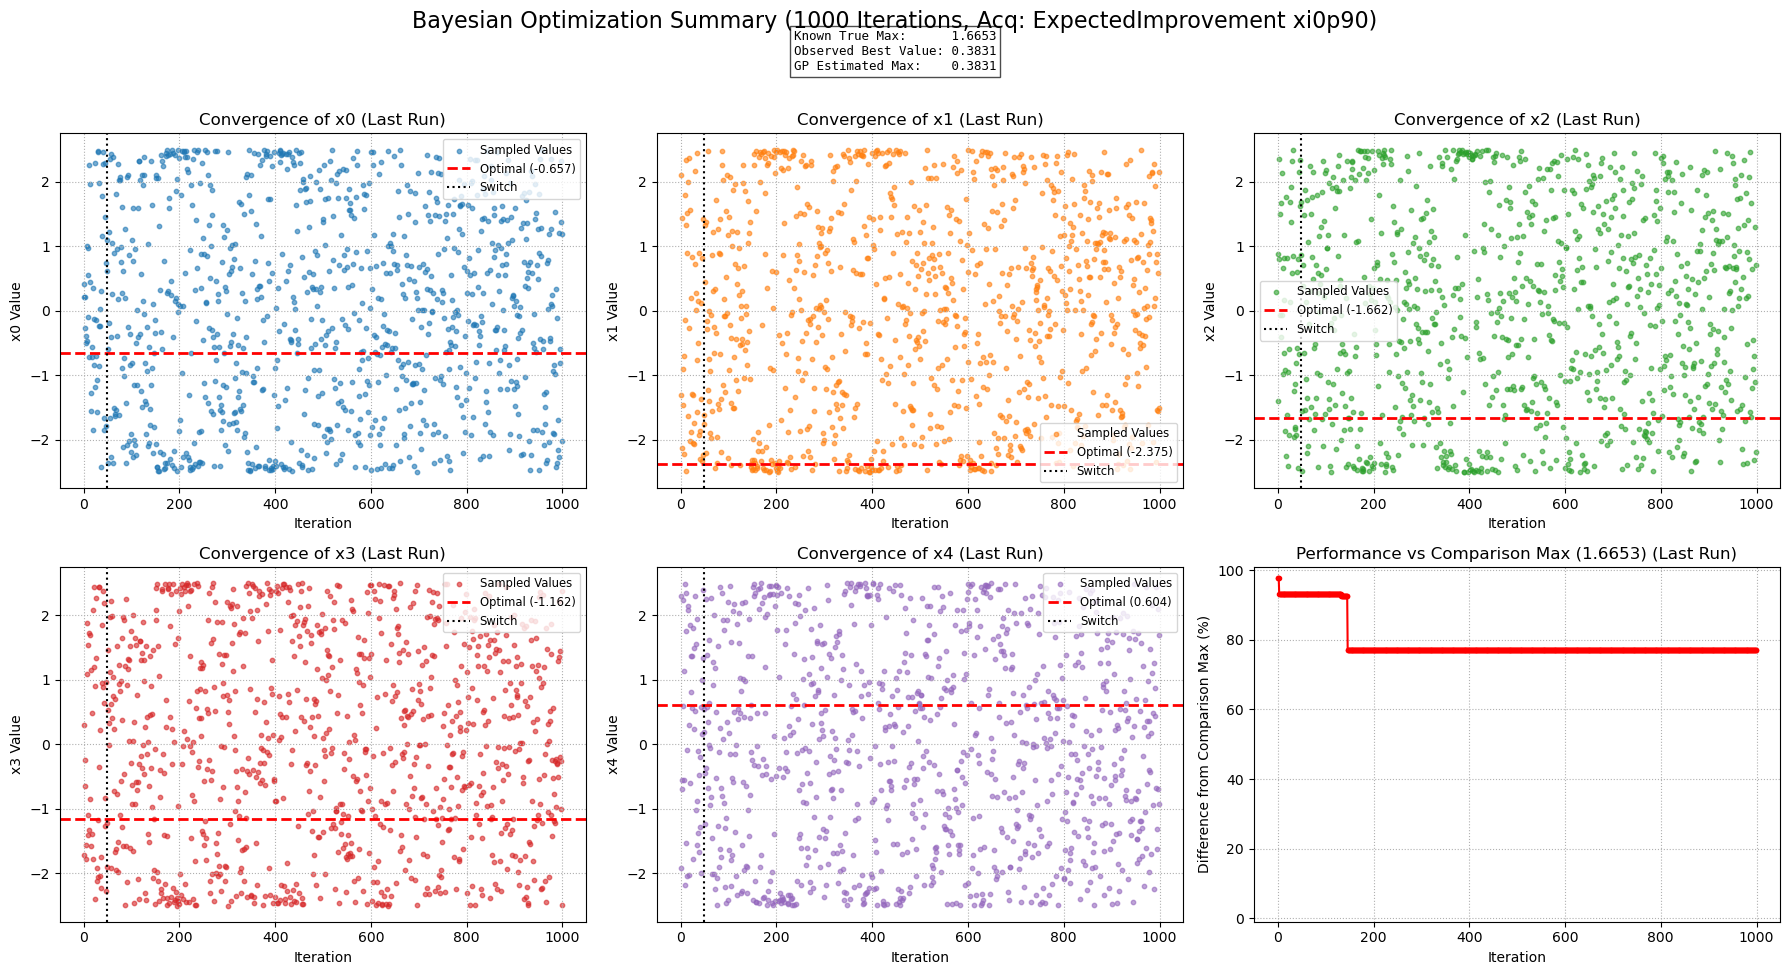

--- 5D Multi-Peak Known Max Experiment Complete ---


In [31]:
# 1. Define Parameters
dim_5d = 5
n_peaks_5d = 6
amp_global_5d = 1.5
amp_local_5d = 0.6
alpha_global_5d = 3.0
alpha_local_5d = 1.0
lower_5d = -2.5
upper_5d = 2.5
noise_5d = 0.0 # Ensure noise is zero
func_seed = 999

# 2. Generate the 5D function
func_5d, pbounds_5d, peaks_info_5d = generate_multi_peak_gaussian(
    dim=dim_5d,
    n_peaks=n_peaks_5d,
    amplitude_global=amp_global_5d,
    amplitude_local=amp_local_5d,
    alpha_global=alpha_global_5d,
    alpha_local=alpha_local_5d,
    lower=lower_5d,
    upper=upper_5d,
    noise=noise_5d, # Pass zero noise
    random_state=func_seed
)
print(f"Generated 5D function: {func_5d.__name__}")

# 3. Calculate the Precise Deterministic Maximum
shifts_arr = peaks_info_5d['shifts']
global_peak_shift = shifts_arr[0] # s0
deterministic_max_value = amp_global_5d # Contribution from global peak at its center

# Add contributions from local peaks at the global peak's location
for i in range(1, n_peaks_5d):
    local_peak_shift = shifts_arr[i]
    distance_sq = np.sum((global_peak_shift - local_peak_shift)**2)
    deterministic_max_value += amp_local_5d * np.exp(-alpha_local_5d * distance_sq)

print(f"Calculated Deterministic Max Value: {deterministic_max_value:.6f}")

# 4. Instantiate Optimizer with Known Max
optimizer_5d_known = BayesOptimizer(
    func=func_5d,
    pbounds=pbounds_5d,
    known_true_max=deterministic_max_value, # Pass the calculated value
    early_stopping_threshold=0.05, # Can use a tighter threshold now
    early_stopping_patience=2,
    verbose=True,
    plot_dir="toy_bayes"
)

# 5. Define Acquisition Function
acquisition_func_5d = ExpectedImprovement(xi=0.9)

# 6. Run the Experiment
print(f"\n--- Running Single {dim_5d}D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---")
single_run_data_5d = optimizer_5d_known.run_experiment(
    acquisition_fn=acquisition_func_5d,
    n_random=50,
    n_acq_max=950,
    approx_max_samples=10000, # Ignored, but still needs a value
    plot_summary=True,
    save_plot=True
)
print("--- 5D Multi-Peak Known Max Experiment Complete ---")

In [32]:
# 1. Define Parameters
dim_5d = 5
n_peaks_5d = 6
amp_global_5d = 1.5
amp_local_5d = 0.6
alpha_global_5d = 5.0
alpha_local_5d = 1.0
lower_5d = -2.5
upper_5d = 2.5
noise_5d = 0.0 # Ensure noise is zero
func_seed = 999

# 2. Generate the 5D function
func_5d, pbounds_5d, peaks_info_5d = generate_multi_peak_gaussian(
    dim=dim_5d,
    n_peaks=n_peaks_5d,
    amplitude_global=amp_global_5d,
    amplitude_local=amp_local_5d,
    alpha_global=alpha_global_5d,
    alpha_local=alpha_local_5d,
    lower=lower_5d,
    upper=upper_5d,
    noise=noise_5d, # Pass zero noise
    random_state=func_seed
)
print(f"Generated 5D function: {func_5d.__name__}")

# 3. Calculate the Precise Deterministic Maximum
shifts_arr = peaks_info_5d['shifts']
global_peak_shift = shifts_arr[0] # s0
deterministic_max_value = amp_global_5d # Contribution from global peak at its center

# Add contributions from local peaks at the global peak's location
for i in range(1, n_peaks_5d):
    local_peak_shift = shifts_arr[i]
    distance_sq = np.sum((global_peak_shift - local_peak_shift)**2)
    deterministic_max_value += amp_local_5d * np.exp(-alpha_local_5d * distance_sq)

print(f"Calculated Deterministic Max Value: {deterministic_max_value:.6f}")

# 4. Instantiate Optimizer with Known Max
optimizer_5d_known = BayesOptimizer(
    func=func_5d,
    pbounds=pbounds_5d,
    known_true_max=deterministic_max_value, # Pass the calculated value
    early_stopping_threshold=0.05, # Can use a tighter threshold now
    early_stopping_patience=2,
    verbose=True,
    plot_dir="toy_bayes"
)

# 5. Define Acquisition Function
acquisition_func_5d = ExpectedImprovement(xi=0.9)

# 6. Run the Experiment
print(f"\n--- Running Single {dim_5d}D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---")
single_run_data_5d = optimizer_5d_known.run_experiment(
    acquisition_fn=acquisition_func_5d,
    n_random=50,
    n_acq_max=950,
    approx_max_samples=10000, # Ignored, but still needs a value
    plot_summary=True,
    save_plot=True
)
print("--- 5D Multi-Peak Known Max Experiment Complete ---")

Generated 5D function: multiPeakGauss_d5_p6_ag1p5_al0p6_alphag5p0_alphal1p0_n0.00
Calculated Deterministic Max Value: 1.665300

--- Running Single 5D Multi-Peak Gaussian Experiment (Zero Noise, Known Max) ---
Using known true maximum for comparison: 1.665300

Starting single optimization run: 50 random, max 950 acquisition steps.
Using Acquisition Function: ExpectedImprovement (xi0p90)


Random Exploration:   0%|          | 0/50 [00:00<?, ?it/s]

Acquisition Phase :   0%|          | 0/950 [00:00<?, ?it/s]

KeyboardInterrupt: 